# Skin Disorder PROJECT

#### **Project Code :**  PRCP-1027-Skin Disorder
### **Project ID :**  PTID-CDS-JAN-26-3819

- **Intern Name:** Saurabh Ghadage,Shreyash Patil, Laxmi Ghulaxe, Suyash Gaikwad

- **Start Date:** Feb 20 2026

- **Domain:** HealthCare Analytics




# Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model  using machine learning techniques to predict the various classes of skin disease. 

Task3:-Suggestions to the Doctors to identify the skin diseases of the patient at the earliest. 


## Dataset Overview

The dataset used in this project belongs to the Healthcare domain and focuses on the differential diagnosis of erythemato-squamous skin diseases.

These diseases share similar clinical and histopathological characteristics, making diagnosis challenging even for experienced dermatologists.

## Dataset Structure

Total Records (Patients): ~366

Total Attributes: 34

Input Features: 33

Target Variable: 1 (Skin Disease Class

# METHODOLOGY


# Step 1: Problem Understanding

## Objective

To build a machine learning model that can accurately classify different types of erythemato-squamous skin diseases using clinical and histopathological features.

## Problem Type

* Supervised Learning
* Multi-class Classification
* Healthcare Domain

---

# Step 2: Data Collection

* Dataset contains 34 attributes
* 33 independent features
* 1 target variable (skin disease class)
* Data includes:

  * Clinical features (visible symptoms)
  * Histopathological features (microscopic observations)
  * Age (numeric feature)

---

# Step 3: Data Understanding

### Activities Performed:

1. Loaded dataset using pandas
2. Checked:

   * Shape of dataset
   * Data types
   * Missing values
   * Unique target classes
3. Verified feature ranges (0–3 scale)

### Key Observations:

* All features numeric except target
* Some age values required cleaning
* Multi-class classification problem identified

---

# Step 4: Data Cleaning

### 1️⃣ Handling Invalid Values

* Converted Age column to numeric
* Replaced missing values with median

### 2️⃣ Duplicate Removal

* Checked for duplicate patient records
* Removed if found

### Reason:

Ensures clean and reliable input for machine learning models.

---

#  Step 5: Exploratory Data Analysis (EDA)

### Analysis Performed:

* Target class distribution
* Age distribution
* Correlation heatmap
* Feature severity distribution
* Outlier detection

### Insights:

* Some class imbalance exists
* Features show meaningful variation across diseases
* No extreme abnormal outliers
* Correlation between medical features is expected

### Purpose:

To understand patterns and relationships before modeling.

---

# Step 6: Feature Engineering

### Techniques Applied:

⃣ Created Aggregate Scores:
* Clinical severity score
* Histopathological severity score

### Reason:

To improve model stability and interpretability.

---

# Step 7: Handling Class Imbalance (SMOTE)

### Why Needed?

Minority disease classes could be underrepresented.

### Method Used:

* Applied SMOTE only on training data
* Balanced class distribution

### Benefit:

Improved recall for minority disease classes.

---

# Step 8: Data Splitting

* 80% Training Data
* 20% Testing Data
* Used stratified sampling

### Reason:

Maintains class distribution and ensures fair evaluation.

---

# Step 9: Model Building

### Models Implemented:

1️⃣ Logistic Regression
2️⃣ K-Nearest Neighbors
3️⃣ Decision Tree
4️⃣ Random Forest

### Approach:

* Trained each model on training data
* Evaluated on test data
* Compared performance

---

# Step 10: Hyperparameter Tuning

### Method Used:

* GridSearchCV with 5-fold cross-validation

### Parameters Tuned:
* Decision Tree → depth, split criteria
* Random Forest → estimators, depth, leaf size

### Reason:

To optimize model performance and prevent overfitting.

---

# Step 11: Model Evaluation

### Metrics Used:

* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix

### Why These Metrics?

In healthcare:

* Recall is very important (avoid missing disease cases)
* Precision ensures correct diagnosis

---

# Step 12: Model Comparison

Compared all models based on:

* Accuracy
* Stability
* Generalization ability
* Minority class performance

### Final Model Selected:

✅ Random Forest (Tuned + SMOTE)

### Reason:

* Highest accuracy
* Balanced performance
* Robust and stable
* Handles complex medical relationships




# Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Load Dataset 

In [5]:
pd.read_csv(r"dataset_35_dermatology.csv")

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


In [6]:
skin_disorder = pd.read_csv(r"dataset_35_dermatology.csv")


# Basic Checks

In [7]:
skin_disorder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [8]:
skin_disorder.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [9]:
skin_disorder.head()


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [10]:
skin_disorder.shape

(366, 35)

In [11]:
# target variable understanding
skin_disorder["class"].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

In [12]:
# columns Names
skin_disorder.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

# Data Preprocessing

In [13]:
skin_disorder.dtypes.value_counts()

int64     34
object     1
Name: count, dtype: int64

In [14]:
skin_disorder.isnull().sum()[skin_disorder.isnull().sum()>0]

Series([], dtype: int64)

In [15]:
# check unique values in age
skin_disorder["Age"].unique()

array(['55', '8', '26', '40', '45', '41', '18', '57', '22', '30', '20',
       '21', '10', '65', '38', '23', '17', '51', '42', '44', '33', '43',
       '50', '34', '?', '15', '46', '62', '35', '48', '12', '52', '60',
       '32', '19', '29', '25', '36', '13', '27', '31', '28', '64', '39',
       '47', '16', '0', '7', '70', '37', '61', '67', '56', '53', '24',
       '58', '49', '63', '68', '9', '75'], dtype=object)

In [16]:
skin_disorder["Age"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 366 entries, 0 to 365
Series name: Age
Non-Null Count  Dtype 
--------------  ----- 
366 non-null    object
dtypes: object(1)
memory usage: 3.0+ KB


In [17]:
# convert age to numeric and errors=coerce convert invalid values to NaN
skin_disorder["Age"] = pd.to_numeric(skin_disorder["Age"],errors="coerce")

In [18]:
# check missing values again
skin_disorder["Age"].isnull().sum()

np.int64(8)

In [19]:
#Handle Missing Age Values
skin_disorder["Age"].fillna(skin_disorder["Age"].median(),inplace=True)

In [20]:
skin_disorder["Age"].isnull().sum()

np.int64(0)

In [21]:
#check for duplicates records
skin_disorder.duplicated().sum()

np.int64(0)

In [22]:
# drop if exist duplicate records
skin_disorder.drop_duplicates(inplace=True)

# Exploratory Data Analysis (EDA)

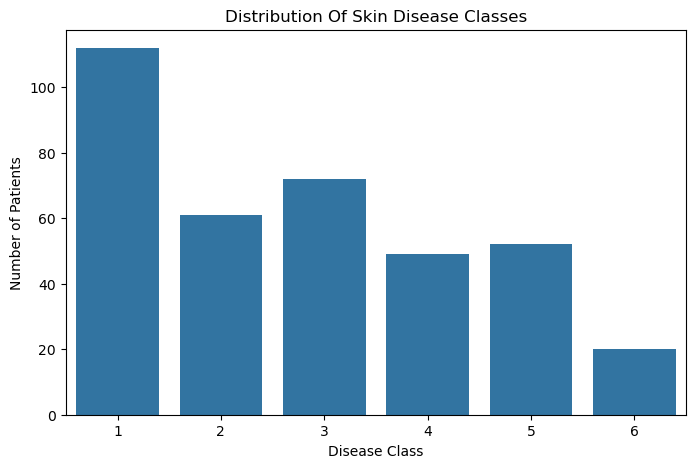

In [23]:
# Target Variable Analysis
plt.figure(figsize=(8,5))
sns.countplot(x="class",data = skin_disorder)
plt.title("Distribution Of Skin Disease Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Patients")
plt.show()

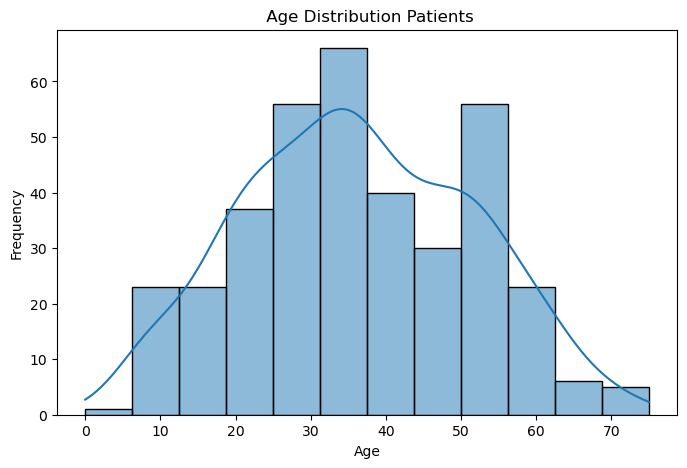

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(skin_disorder["Age"],kde=True)
plt.title(" Age Distribution Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [25]:
num = skin_disorder.drop("class",axis=1).columns
num

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age'],
      dtype='object')

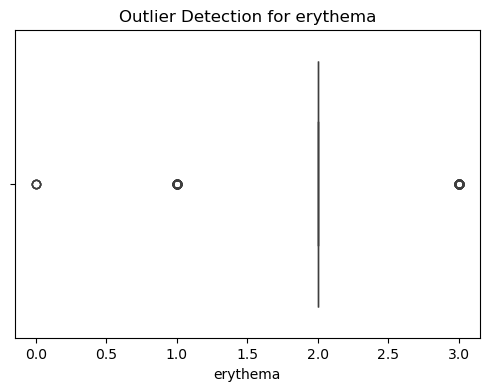

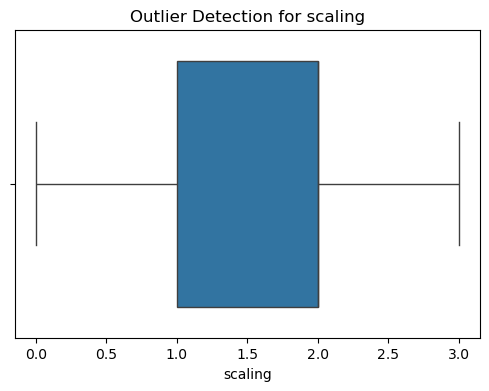

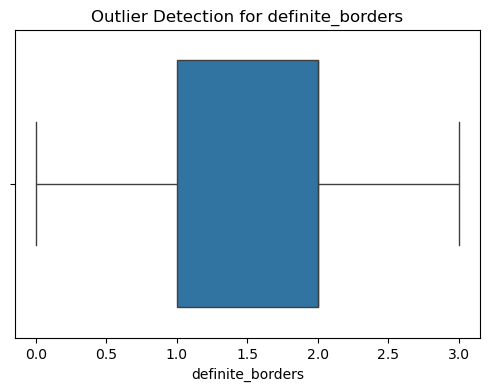

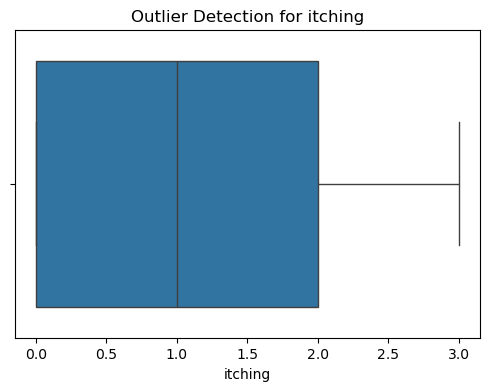

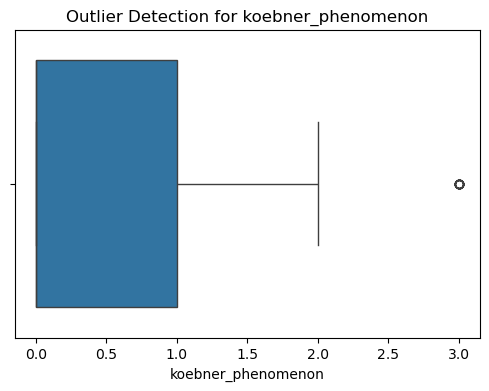

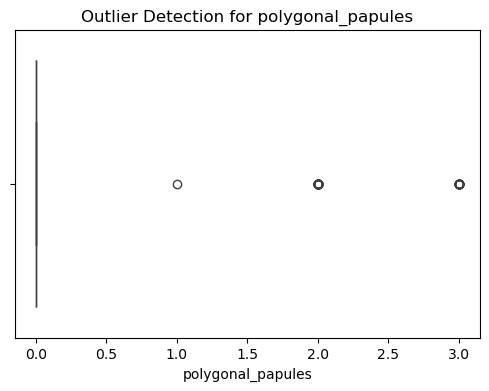

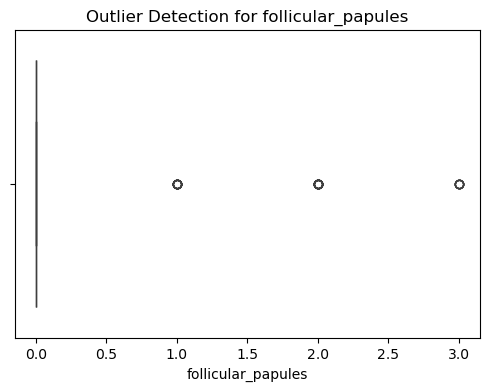

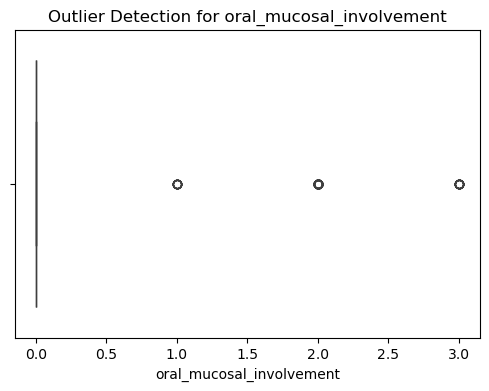

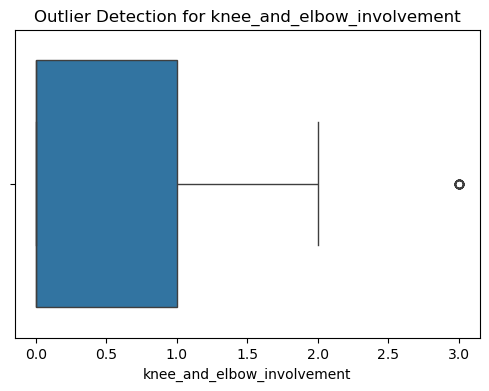

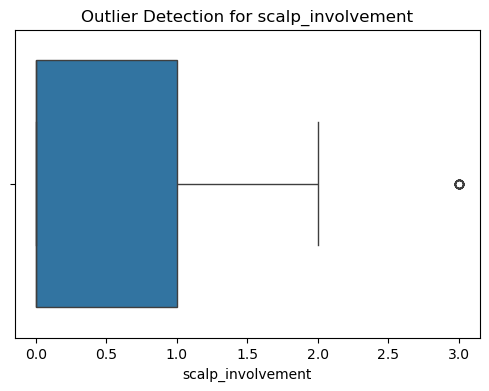

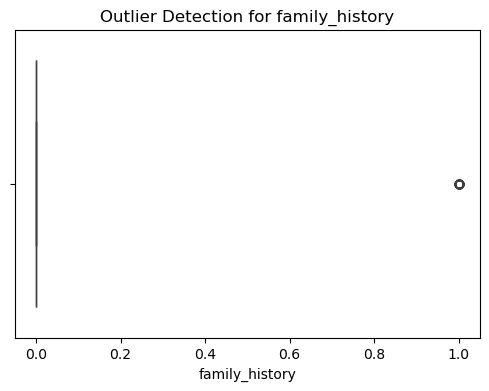

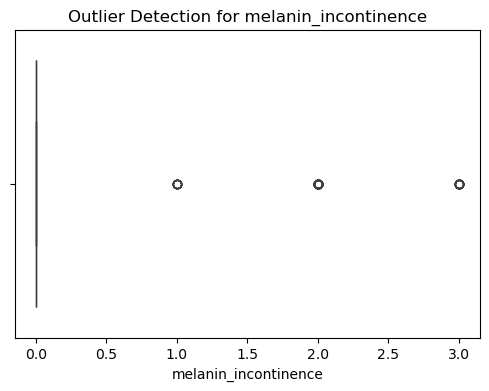

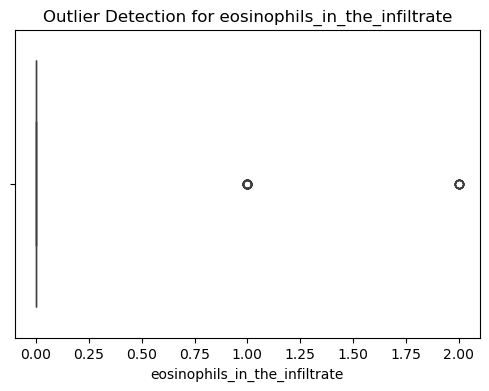

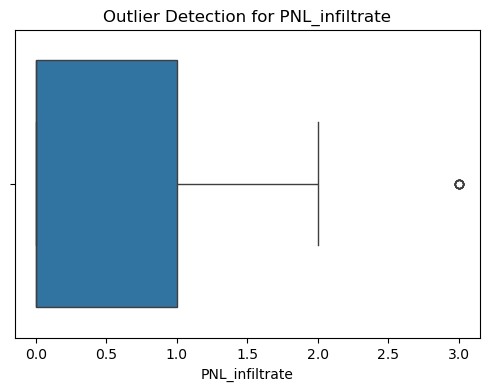

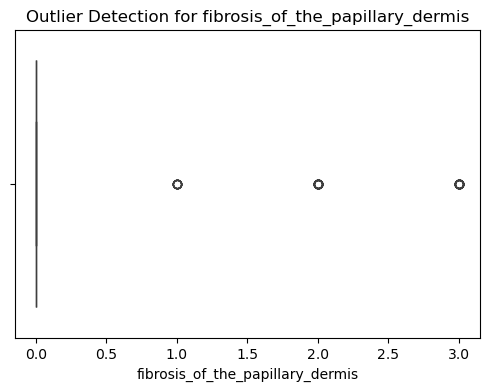

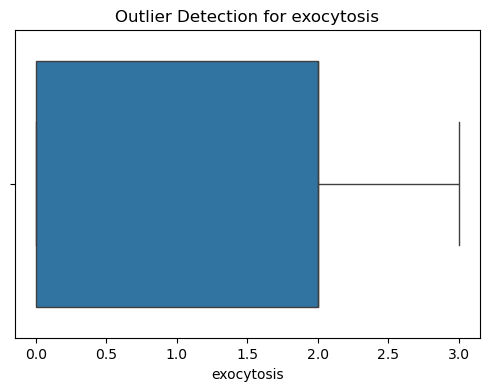

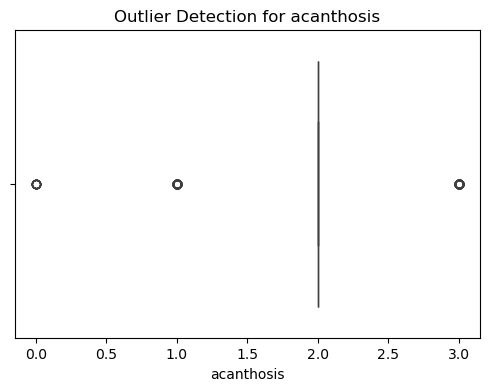

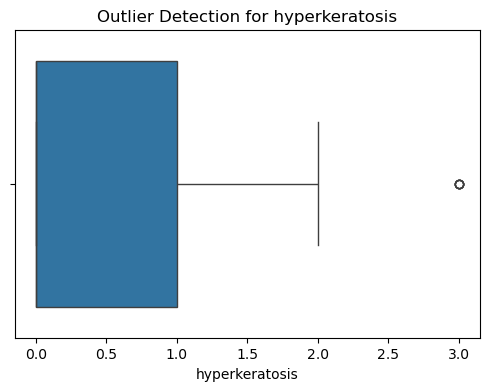

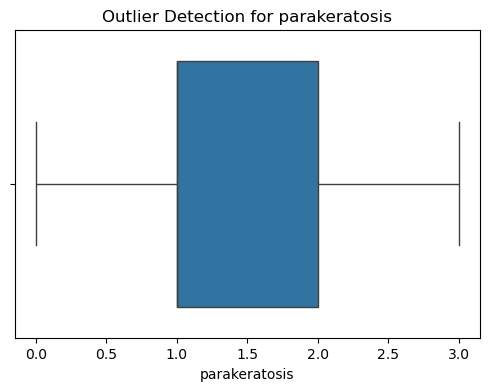

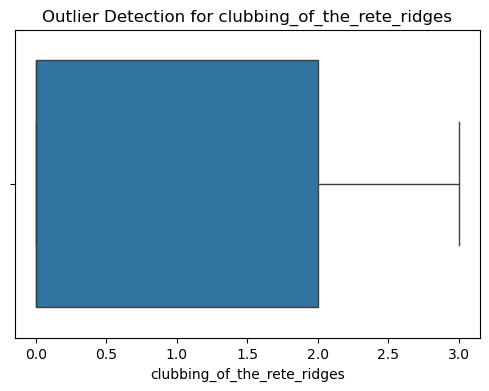

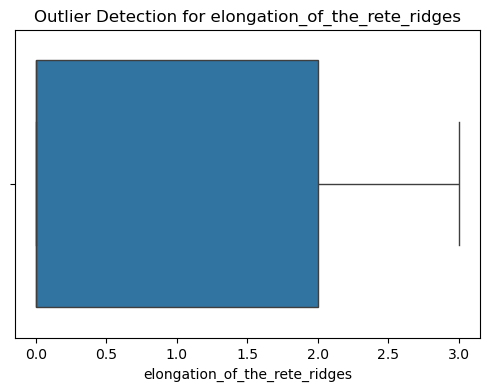

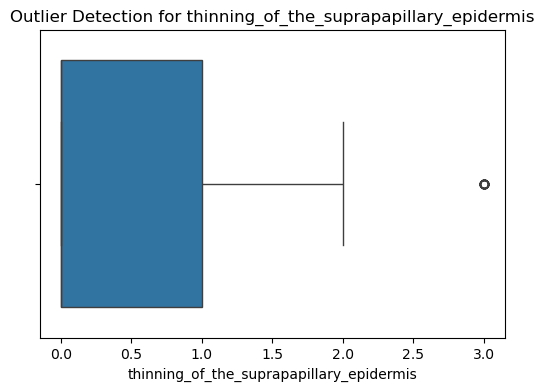

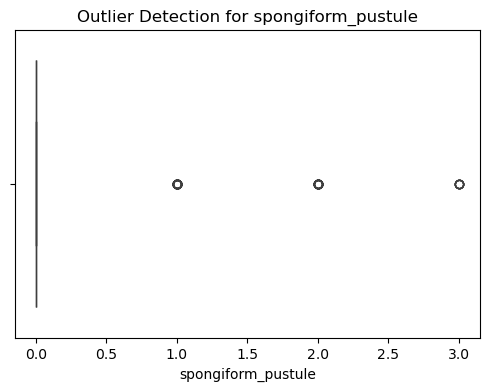

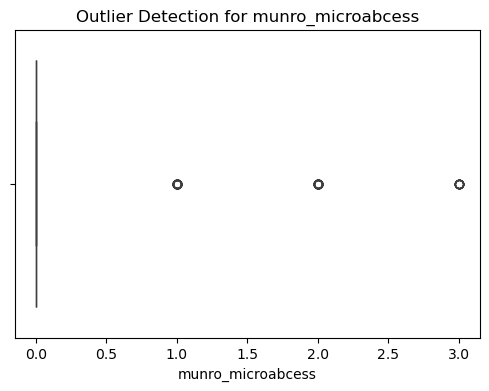

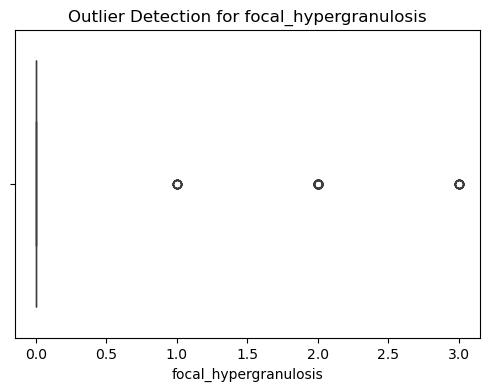

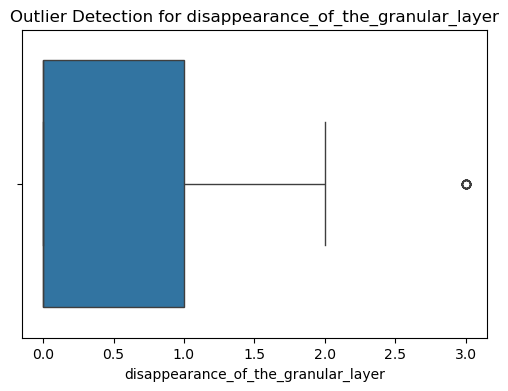

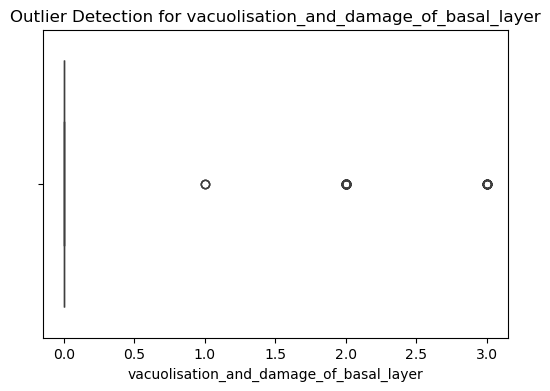

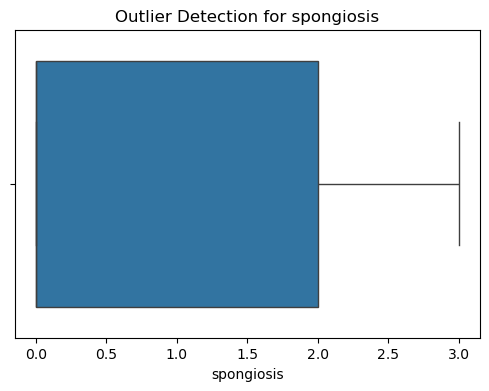

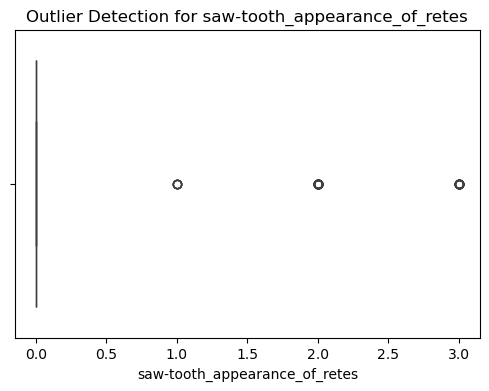

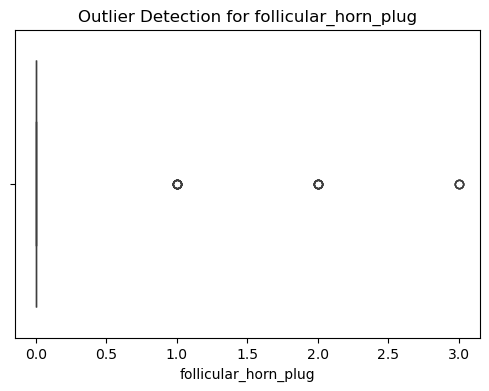

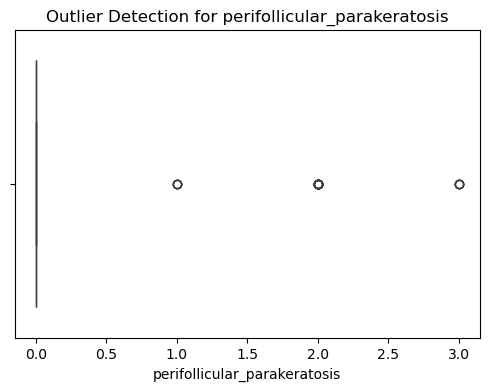

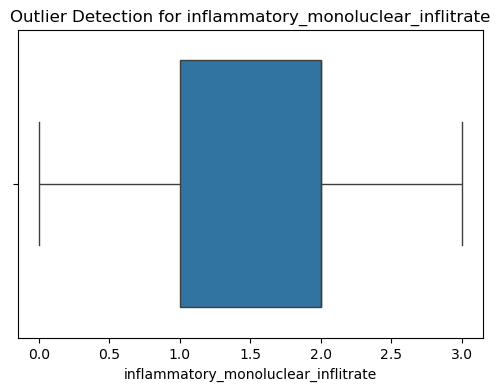

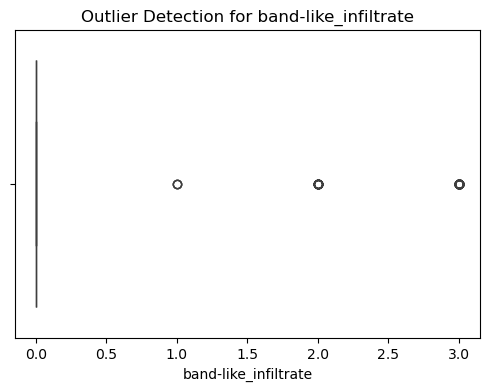

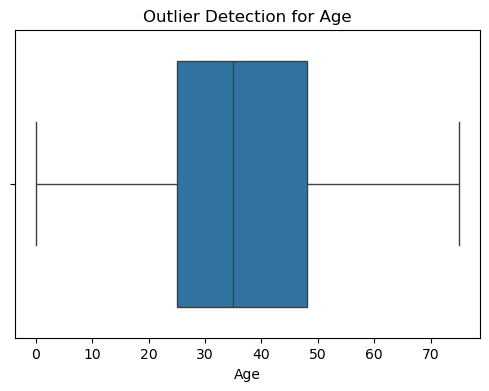

In [26]:
# most features do not show  extreme outliers and age show some ouliers which are clinically valid
# removing outliers may lose critical medical conditions

for col in num:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=skin_disorder[col])
    plt.title(f"Outlier Detection for {col}")
    plt.show()

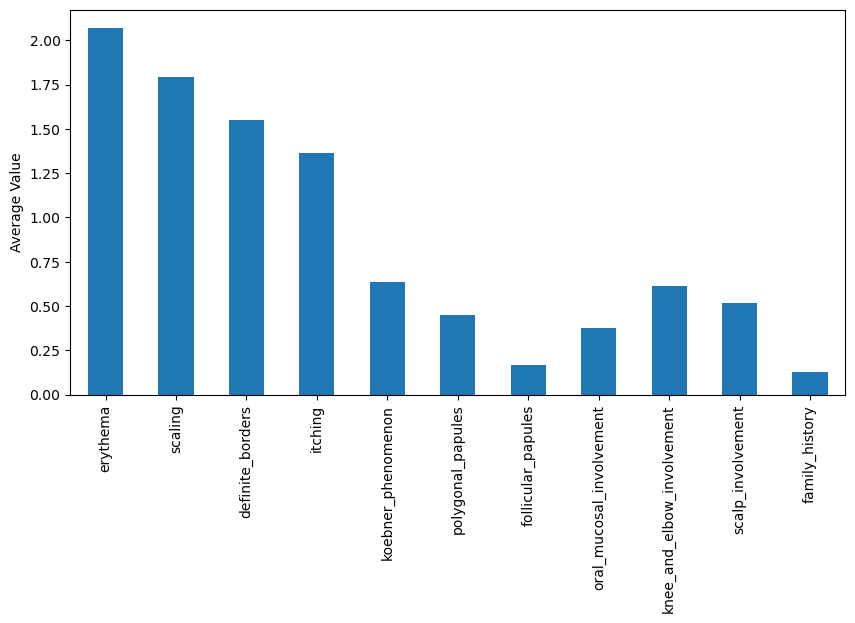

In [27]:
clinical_feature = skin_disorder.columns[0:11]
skin_disorder[clinical_feature].mean().plot(kind="bar",figsize=(10,5))
plt.ylabel("Average Value")
plt.show()

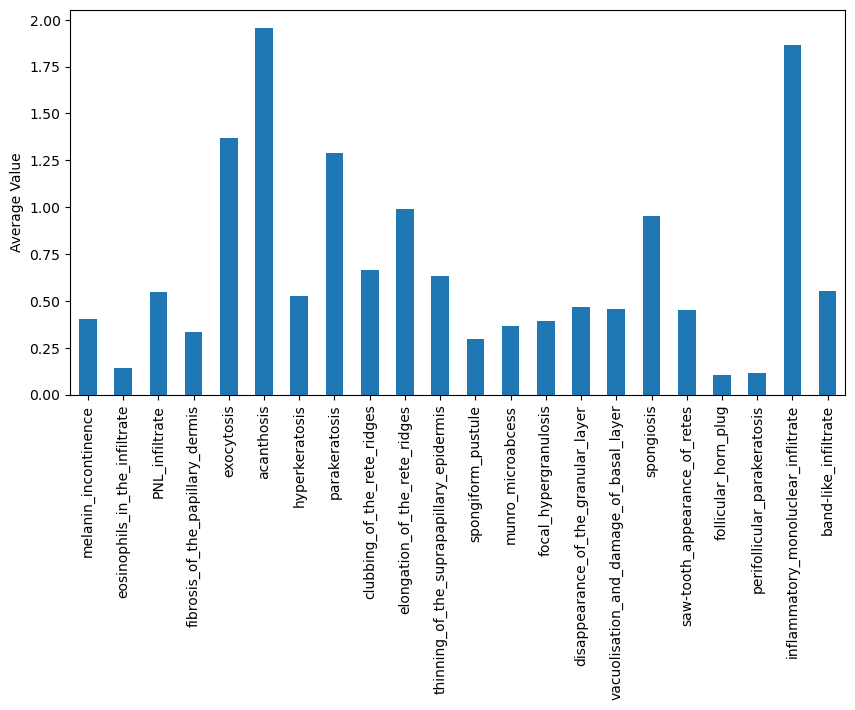

In [28]:
histopathological_feature = skin_disorder.columns[11:33]
skin_disorder[histopathological_feature].mean().plot(kind="bar",figsize=(10,5))
plt.ylabel("Average Value")
plt.show()

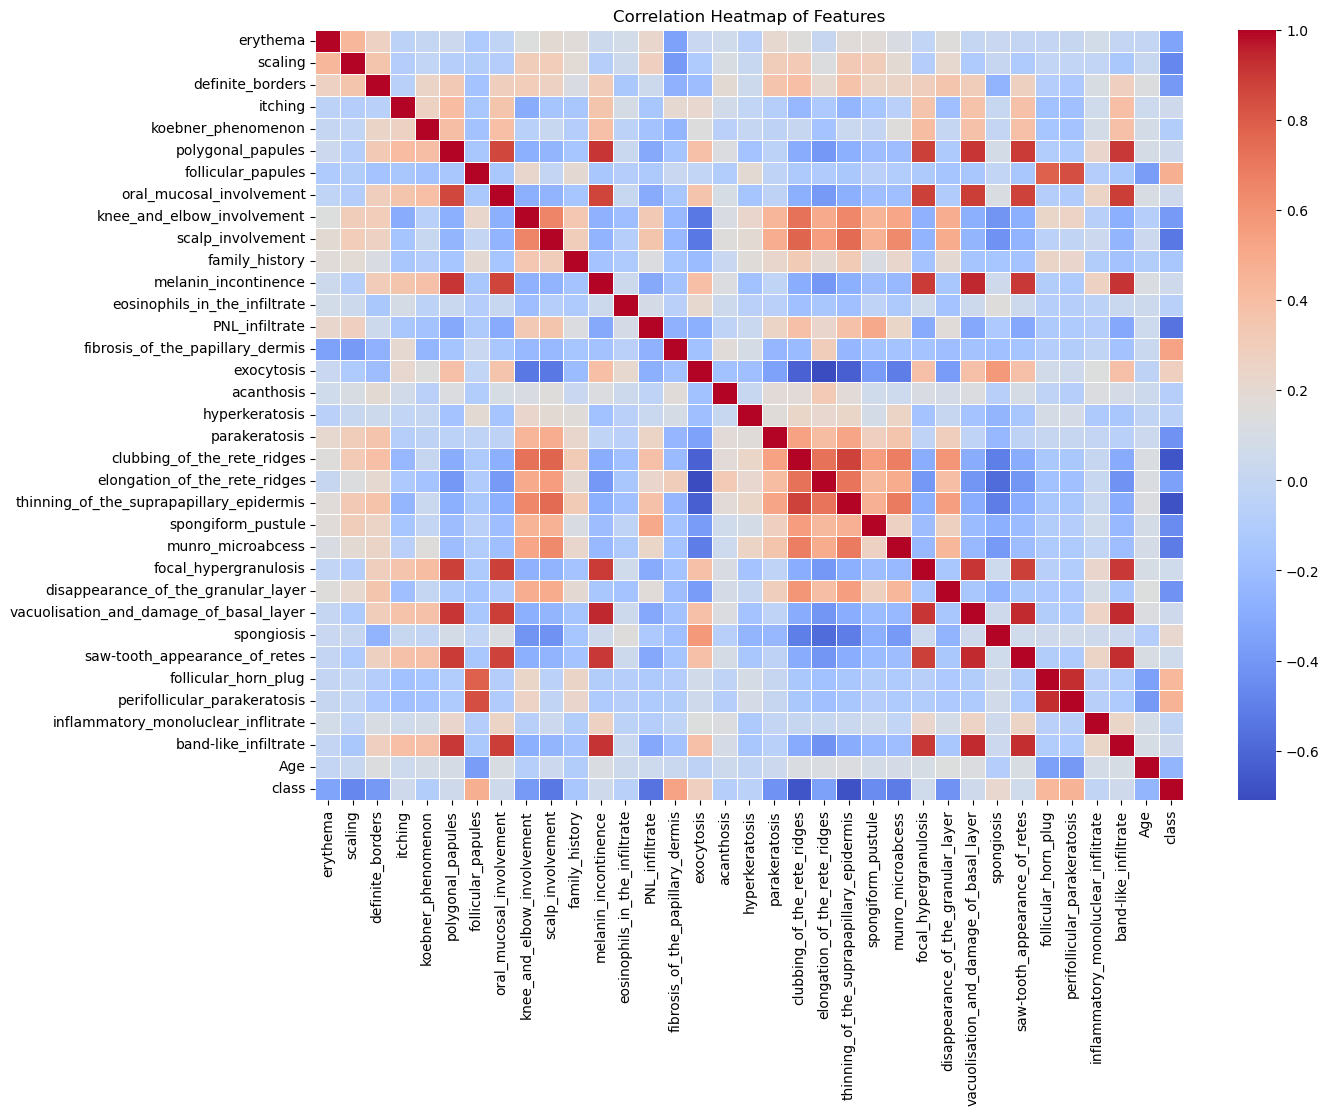

In [29]:
plt.figure(figsize=(14,10))
sns.heatmap(skin_disorder.corr(),cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

# Feature & Target Split

In [30]:
x = skin_disorder.drop("class",axis=1)
y = skin_disorder["class"]

# Train Test Split

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# SMOTE Implemetation
dataset is mild class imbalance and in healthcare applications misclassifying minority disease classes can be critical . SMOTE helps create synthetic samples to balance the dataset and improve recall for rare classes

In [32]:
skin_disorder["class"].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

In [33]:
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [36]:
y_train_smote.value_counts()

class
5    81
2    81
1    81
4    81
3    81
6    81
Name: count, dtype: int64

# Model Building

# 1. Logistic Regression

In [37]:
lr=LogisticRegression(max_iter=2000)
lr.fit(x_train_smote,y_train_smote)

lr_pred = lr.predict(x_test)

lr_acc = accuracy_score(y_test,lr_pred)


In [38]:
print("Accuracy=",lr_acc) 
print("Classification Report =\n",classification_report(y_test,lr_pred))
print("Confusion Matrix =\n",confusion_matrix(y_test,lr_pred))


Accuracy= 0.9594594594594594
Classification Report =
               precision    recall  f1-score   support

           1       1.00      0.97      0.98        31
           2       0.82      1.00      0.90         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       0.67      0.67      0.67         3

    accuracy                           0.96        74
   macro avg       0.91      0.92      0.91        74
weighted avg       0.96      0.96      0.96        74

Confusion Matrix =
 [[30  0  0  0  0  1]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  1  0  0  0  2]]


# 2. Decision Tree

In [39]:
dt=DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth":[None,5,10,15,20],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"]
}

dt_grid = GridSearchCV(
    estimator = dt,
    param_grid = dt_params,
    cv=5,
    scoring = "accuracy"
)

dt_grid.fit(x_train_smote,y_train_smote)

best_dt = dt_grid.best_estimator_

dt_pred=best_dt.predict(x_test)

dt_acc = accuracy_score(y_test,dt_pred)


In [40]:
print("Accuracy=",dt_acc )
print("Classification Report =\n",classification_report(y_test,dt_pred))
print("Confusion Matrix =\n",confusion_matrix(y_test,dt_pred))

Accuracy= 0.9459459459459459
Classification Report =
               precision    recall  f1-score   support

           1       1.00      0.94      0.97        31
           2       0.69      1.00      0.82         9
           3       1.00      0.85      0.92        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.95        74
   macro avg       0.95      0.96      0.95        74
weighted avg       0.96      0.95      0.95        74

Confusion Matrix =
 [[29  2  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  2 11  0  0  0]
 [ 0  0  0  8  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


# 3.KNN

In [41]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_smote,y_train_smote)

knn_pred=knn.predict(x_test)

knn_acc = accuracy_score(y_test,knn_pred)


In [42]:
print("Accuracy=",knn_acc) 
print("Classification Report =\n",classification_report(y_test,knn_pred))
print("Confusion Matrix =\n",confusion_matrix(y_test,knn_pred))

Accuracy= 0.8378378378378378
Classification Report =
               precision    recall  f1-score   support

           1       1.00      0.87      0.93        31
           2       0.58      0.78      0.67         9
           3       1.00      1.00      1.00        13
           4       0.56      0.62      0.59         8
           5       0.89      0.80      0.84        10
           6       0.50      0.67      0.57         3

    accuracy                           0.84        74
   macro avg       0.75      0.79      0.77        74
weighted avg       0.87      0.84      0.85        74

Confusion Matrix =
 [[27  2  0  0  0  2]
 [ 0  7  0  2  0  0]
 [ 0  0 13  0  0  0]
 [ 0  2  0  5  1  0]
 [ 0  0  0  2  8  0]
 [ 0  1  0  0  0  2]]


# 4.Random Forest

In [43]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

rf_grid = GridSearchCV(
    estimator = rf,
    param_grid = rf_params,
    cv=5,
    scoring = "accuracy"
)

rf_grid.fit(x_train_smote,y_train_smote)

best_rf = rf_grid.best_estimator_

rf_pred=best_rf.predict(x_test)

rf_acc = accuracy_score(y_test,rf_pred)

In [44]:
print("Accuracy=",rf_acc) 
print("Classification Report =\n",classification_report(y_test,rf_pred))
print("Confusion Matrix =\n",confusion_matrix(y_test,rf_pred))

Accuracy= 0.9864864864864865
Classification Report =
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Confusion Matrix =
 [[31  0  0  0  0  0]
 [ 0  9  0  0  0  0]
 [ 0  0 13  0  0  0]
 [ 0  1  0  7  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  3]]


# Model Comaprison Report

In [45]:
model_comparision = pd.DataFrame({
    "model":["Logistic Regression","Decision Tree","KNeighborsClassifier","Random Forest"],
    "Accuracy":[lr_acc,dt_acc,knn_acc,rf_acc]
})

model_comparision

,model,Accuracy
0,Logistic Regression,0.959459
1,Decision Tree,0.945946
2,KNeighborsClassifier,0.837838
3,Random Forest,0.986486


# Confusion Matrix

In [ ]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

### Suggestions to Doctors

1. Early detection using family history and erythema severity.
2. Age factor plays an important role.
3. Combination of clinical and histopathological features improves prediction accuracy.
4. Random Forest model can assist in early stage detection.

### Challenges Faced

1. Missing values in Age column.
2. Multiclass classification problem.
3. Some features highly correlated.
4. Required feature scaling.

Techniques Used:
- Median imputation for missing values.
- StandardScaler for normalization.
- Random Forest to handle feature importance.

# Final Conclusion

The objective of this project was to analyze clinical and histopathological data of patients and develop a machine learning model capable of accurately predicting different types of erythemato-squamous skin diseases.

Through a structured and systematic methodology, the project successfully:

1.Cleaned and validated the medical dataset

2.Performed detailed exploratory data analysis to understand disease patterns

3.Engineered meaningful features to enhance interpretability

4.Addressed class imbalance using SMOTE

5.Built and compared multiple classification models

6.Applied hyperparameter tuning to optimize performance

Among all the models tested —* Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest * — **the Tuned Random Forest model** demonstrated the best overall performance in terms of accuracy, stability, and balanced class prediction.

The model effectively captured complex non-linear relationships between clinical and microscopic features, making it highly suitable for healthcare classification tasks.

From a practical perspective, this system can:

1.Assist dermatologists in early disease identification

2.Reduce dependency on invasive biopsy procedures

3.Improve diagnostic speed and confidence

4.Support junior doctors in decision-making

5.Enhance overall patient care through data-driven insights

In conclusion, this project demonstrates how machine learning can act as an intelligent decision-support tool in the healthcare domain. By combining clinical expertise with predictive modeling, it is possible to improve diagnostic accuracy and contribute to better treatment outcomes.